In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import joblib

In [6]:
df = pd.read_csv("../data/StudentsPerformance.csv")

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [7]:
df.info()
df.shape
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [9]:
df["pass"] = (df["math score"] >= 50).astype(int)

df[["math score", "pass"]].head(10)

,math score,pass
0,72,1
1,69,1
2,90,1
3,47,0
4,76,1
5,71,1
6,88,1
7,40,0
8,64,1
9,38,0


In [10]:
df[["math score", "pass"]].head(10)

,math score,pass
0,72,1
1,69,1
2,90,1
3,47,0
4,76,1
5,71,1
6,88,1
7,40,0
8,64,1
9,38,0


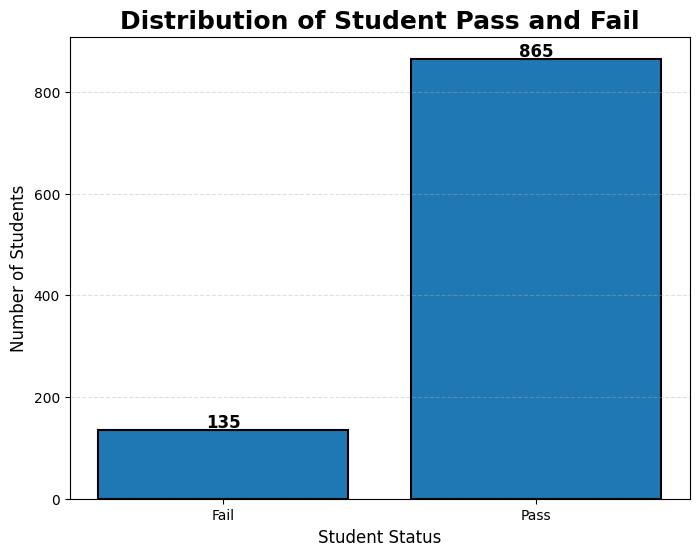

In [13]:
plt.figure(figsize=(8,6))

counts = df["pass"].value_counts().sort_index()

bars = plt.bar(
    ["Fail", "Pass"],
    [counts[0], counts[1]],
    edgecolor="black",
    linewidth=1.5
)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 5,
        f"{int(height)}",
        ha="center",
        fontsize=12,
        fontweight="bold"
    )

plt.title("Distribution of Student Pass and Fail",
          fontsize=18,
          fontweight="bold")

plt.xlabel("Student Status", fontsize=12)
plt.ylabel("Number of Students", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.savefig(
    "../images/pass_fail_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

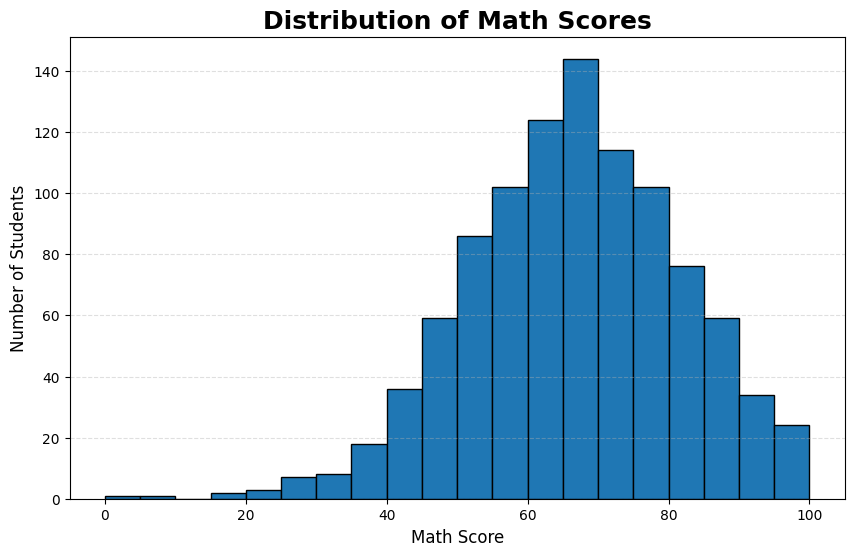

In [15]:
plt.figure(figsize=(10,6))

plt.hist(
    df["math score"],
    bins=20,
    edgecolor="black"
)

plt.title(
    "Distribution of Math Scores",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Math Score", fontsize=12)
plt.ylabel("Number of Students", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.savefig(
    "../images/math_score_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

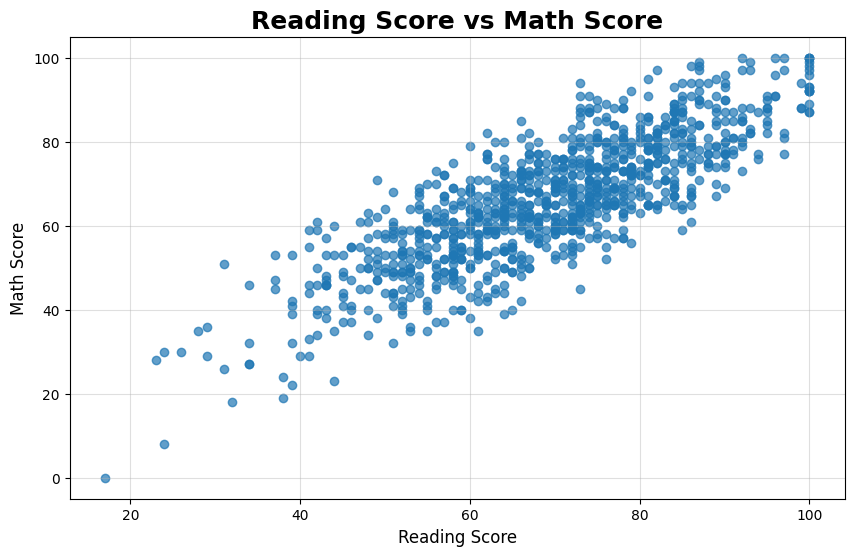

In [18]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["reading score"],
    df["math score"],
    alpha=0.7
)

plt.title(
    "Reading Score vs Math Score",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Reading Score", fontsize=12)
plt.ylabel("Math Score", fontsize=12)

plt.grid(alpha=0.4)

plt.savefig(
    "../images/reading_vs_math.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

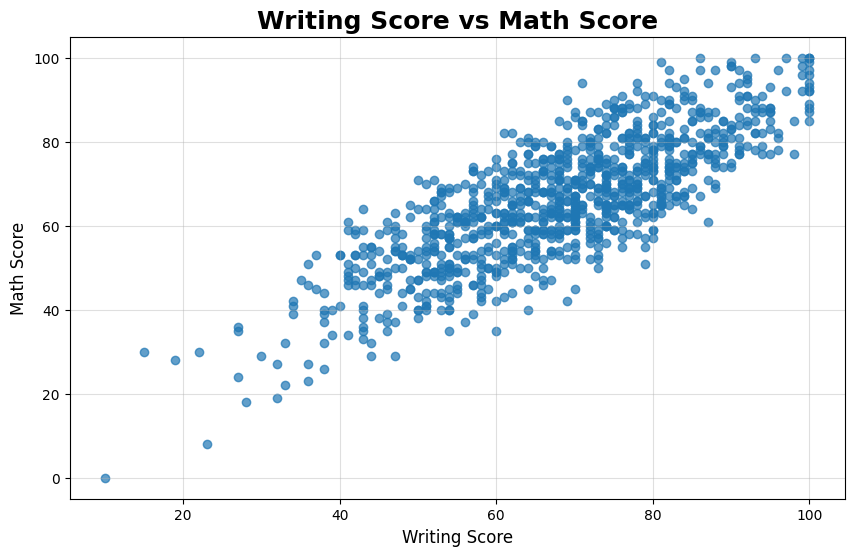

In [19]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["writing score"],
    df["math score"],
    alpha=0.7
)

plt.title(
    "Writing Score vs Math Score",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Writing Score", fontsize=12)
plt.ylabel("Math Score", fontsize=12)

plt.grid(alpha=0.4)

plt.savefig(
    "../images/writing_vs_math.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()




,math score,reading score,writing score,pass,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_standard,test preparation course_none
0,72,72,74,1,False,True,False,False,False,True,False,False,False,False,True,True
1,69,90,88,1,False,False,True,False,False,False,False,False,True,False,True,False
2,90,95,93,1,False,True,False,False,False,False,False,True,False,False,True,True
3,47,57,44,0,True,False,False,False,False,False,False,False,False,False,False,True
4,76,78,75,1,True,False,True,False,False,False,False,False,True,False,True,True


In [23]:
print(df_encoded.columns)

Index(['math score', 'reading score', 'writing score', 'pass', 'gender_male',
       'race/ethnicity_group B', 'race/ethnicity_group C',
       'race/ethnicity_group D', 'race/ethnicity_group E',
       'parental level of education_bachelor's degree',
       'parental level of education_high school',
       'parental level of education_master's degree',
       'parental level of education_some college',
       'parental level of education_some high school', 'lunch_standard',
       'test preparation course_none'],
      dtype='str')


In [24]:
X = df_encoded.drop(["math score", "pass"], axis=1)

y = df_encoded["pass"]

In [30]:
print(X.shape)
print(y.shape)


(1000, 14)
(1000,)


In [29]:
df_encoded = pd.get_dummies(df, drop_first=True)
print(df_encoded.columns)

X = df_encoded.drop(["math score", "pass"], axis=1)

y = df_encoded["pass"]

Index(['math score', 'reading score', 'writing score', 'pass', 'gender_male',
       'race/ethnicity_group B', 'race/ethnicity_group C',
       'race/ethnicity_group D', 'race/ethnicity_group E',
       'parental level of education_bachelor's degree',
       'parental level of education_high school',
       'parental level of education_master's degree',
       'parental level of education_some college',
       'parental level of education_some high school', 'lunch_standard',
       'test preparation course_none'],
      dtype='str')


In [31]:
print(X.shape)
print(y.shape)

(1000, 14)
(1000,)


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [33]:
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

print()

print("Training Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)

Training Features: (800, 14)
Testing Features : (200, 14)

Training Labels : (800,)
Testing Labels  : (200,)


In [34]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [35]:
predictions = model.predict(X_test)

predictions[:10]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [36]:
df["pass"].value_counts()

pass
1    865
0    135
Name: count, dtype: int64

In [37]:
accuracy = accuracy_score(y_test, predictions)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9400


In [40]:
cm = confusion_matrix(y_test, predictions)

print(cm)

[[ 21   6]
 [  6 167]]


In [39]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.78      0.78      0.78        27
           1       0.97      0.97      0.97       173

    accuracy                           0.94       200
   macro avg       0.87      0.87      0.87       200
weighted avg       0.94      0.94      0.94       200



In [41]:
LogisticRegression(class_weight='balanced')

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good defau

<Figure size 600x500 with 0 Axes>

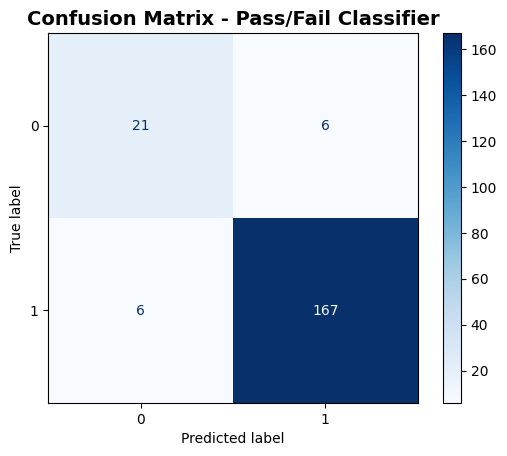

In [45]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    cmap="Blues"
)

plt.title("Confusion Matrix - Pass/Fail Classifier",
          fontsize=14,
          fontweight="bold")

plt.savefig("../images/confusion_matrix.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [46]:
import joblib

joblib.dump(model, "../model/pass_fail_model.pkl")

['../model/pass_fail_model.pkl']